In [146]:
# --------------------------------------------------------------
#  Toyota car model CNN
# --------------------------------------------------------------

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
import time
from datetime import timedelta

# --------------------------  SEED  ---------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)          # for multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# --------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print("Using seed:", SEED)
# --------------------------------------------------------------

Using device: cuda
Using seed: 42


In [147]:
# -----------------------  PARAMETERS  ------------------------
BATCH_SIZE       = 32   # batch size
IMAGE_SIZE       = 224  # 224x224 images
BASE_LR          = 1e-3 # base learning rate
WEIGHT_DECAY     = 1e-4 # weight decay for optimizer
WARMPUP_EPOCHS   = 3    # number of warm-up epochs
EPOCHS_BASE      = 50   # number of training epochs
EPOCHS_TL        = 10   # number of transfer learning epochs
WIDTH_FACTOR     = 1    # width factor for model channels
PATIENCE         = 10   # early stopping patience
# --------------------------------------------------------------
DATA_ROOT        = "./toyota_intact_dataset"
SELECTED_CLASSES = ["revo_v2", "verso_v2", "aygo_v2", "venza_v2", "supra_v2"]
# --------------------------------------------------------------
TRAIN_TEST_SPLIT = 0.8  # 80%-20% train/test split
TRAIN_VAL_SPLIT  = 0.9  # 90%-10% train/val split
# --------------------------------------------------------------

# 2k images
# camry
# corolla

# 1k images
# 4runner
# highlander
# prius
# rav4 (1.8K)
# tacoma
# tundra

# 400-500 images
# avalon_v2
# hilux_v2

# 200-300 images
# fortuner_v2

# 100-200 images
# supra_v2
# venza_v2
# aygo_v2
# revo_v2
# sequoia_v2
# verso_v2
# vios_v2

In [148]:
# -----------------------  TRANSFORMS  ------------------------

mean_values = [0.485, 0.456, 0.406]  # ImageNet mean values for normalization
std_values  = [0.229, 0.224, 0.225]  # ImageNet std values for normalization

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # redimensiona la imagen
    transforms.RandomHorizontalFlip(p=0.5),  # voltea horizontalmente con probabilidad 0.5
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),  # recorte y escalado aleatorio
    transforms.RandomRotation(degrees=10),  # rotación a la imagen aleatoria
    transforms.ColorJitter(hue=0.2, brightness=0.2, contrast=0.2, saturation=0.2),  # altera color/contraste/tono
    transforms.ToTensor(),  # convierte PIL->Tensor y normaliza rango [0,1]
    transforms.Normalize(mean=mean_values,  # normaliza con medias de ImageNet
                         std=std_values),  # desviaciones estándar de ImageNet
])

# https://docs.pytorch.org/vision/stable/transforms.html#torchvision.transforms.Normalize
# for normalization, we use the standard ImageNet values

test_transform = transforms.Compose([  # transformaciones para validación/prueba (determinísticas)
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # redimensiona al tamaño objetivo
    transforms.ToTensor(),  # convierte a tensor
    transforms.Normalize(mean=mean_values,  # normaliza con medias ImageNet
                         std=std_values),  # normaliza con std ImageNet
])

# --------------------------------------------------------------

In [149]:
from PIL import Image

class ToyotaDataset(Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        """
        image_paths: List of file paths to images
        labels: List of integer labels corresponding to image_paths
        class_to_idx: Dictionary mapping class names to integers (for reference)
        transform: PyTorch transform to apply
        """
        self.image_paths = image_paths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

In [150]:
from sklearn.model_selection import train_test_split
import glob

def create_datasets(root_dir, selected_classes, train_transform, test_transform):
    """
    Creates Train, Val, and Test datasets with stratified splitting.
    """
    all_paths = []
    all_labels = []
    
    # 1. Map class names to indices (0, 1, 2...)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(selected_classes)}
    
    print(f"Loading specific classes: {selected_classes}...")

    # 2. FAST LOAD: Only scan specific folders
    for cls_name in selected_classes:
        class_dir = os.path.join(root_dir, cls_name)
        
        # Get all valid image files in that folder
        # Uses glob for pattern matching (jpg, png, etc.)
        files = glob.glob(os.path.join(class_dir, "*.*")) 
        # Filter for common image extensions if folder allows junk files
        files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        
        if len(files) == 0:
            print(f"Warning: No images found for {cls_name}")
            continue
            
        all_paths.extend(files)
        # Create a label list of the same length
        all_labels.extend([class_to_idx[cls_name]] * len(files))
        
        print(f"Found {len(files)} images for class '{cls_name}'")

    print(f"Total images found: {len(all_paths)}")

    # 3. STRATIFIED SPLIT
    # Goal: 80% Train+Val, 20% Test
    # The 'stratify' parameter ensures the class distribution is preserved
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        all_paths, all_labels, 
        test_size=1-TRAIN_TEST_SPLIT, 
        stratify=all_labels, # <--- This guarantees class balance
        random_state=SEED
    )

    # Goal: From the 80% (Train+Val), split 90% Train, 10% Val
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, 
        test_size=1-TRAIN_VAL_SPLIT, # 10% of the 80% chunk
        stratify=train_val_labels, # <--- Keeps balance in validation too
        random_state=SEED
    )

    # 4. Instantiate Datasets with specific transforms
    train_ds = ToyotaDataset(train_paths, train_labels, class_to_idx, transform=train_transform)
    val_ds   = ToyotaDataset(val_paths, val_labels, class_to_idx, transform=test_transform)
    test_ds  = ToyotaDataset(test_paths, test_labels, class_to_idx, transform=test_transform)

    return train_ds, val_ds, test_ds

In [151]:
train_set, val_set, test_set = create_datasets(
    root_dir=DATA_ROOT,
    selected_classes=SELECTED_CLASSES,
    train_transform=train_transform,
    test_transform=test_transform
)

# 3. Verify the Balance (Optional check)
from collections import Counter
print("\n--- Distribution Check ---")
print(f"Train size: {len(train_set)}")
print(f"Validation size:   {len(val_set)}")
print(f"Test size:  {len(test_set)}")
print("Test Set Class Counts:", sorted(Counter([y for _, y in test_set]).items()))

# 4. Create Loaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

Loading specific classes: ['revo_v2', 'verso_v2', 'aygo_v2', 'venza_v2', 'supra_v2']...
Found 122 images for class 'revo_v2'
Found 101 images for class 'verso_v2'
Found 100 images for class 'aygo_v2'
Found 103 images for class 'venza_v2'
Found 165 images for class 'supra_v2'
Total images found: 591

--- Distribution Check ---
Train size: 424
Validation size:   48
Test size:  119
Test Set Class Counts: [(0, 25), (1, 20), (2, 20), (3, 21), (4, 33)]


In [152]:
def plot_loader_data(loader):
    fig, axes = plt.subplots(1, len(SELECTED_CLASSES), figsize=(15, 5))
    shown_classes = set()
    shown_indices = []
    print("Image size: ", loader.dataset[0][0].shape)

    for idx, (img, label) in enumerate(loader.dataset):
        class_name = SELECTED_CLASSES[label]
        if class_name not in shown_classes:
            shown_classes.add(class_name)
            shown_indices.append(idx)
        if len(shown_indices) == len(SELECTED_CLASSES):
            break

    for ax, idx in zip(axes, shown_indices):
        img, label = loader.dataset[idx]
        image = img.permute(1, 2, 0)
        denormalized_img = image * torch.tensor(std_values) + torch.tensor(mean_values)
        ax.imshow(denormalized_img)
        ax.set_title(SELECTED_CLASSES[label])
        ax.axis('off')

    plt.show()

Image size:  torch.Size([3, 224, 224])


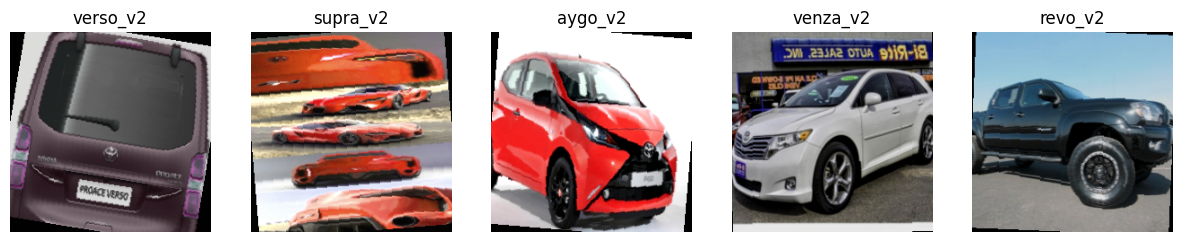

In [153]:
# TRAIN SET SAMPLE VISUALIZATION
plot_loader_data(train_loader)

Image size:  torch.Size([3, 224, 224])


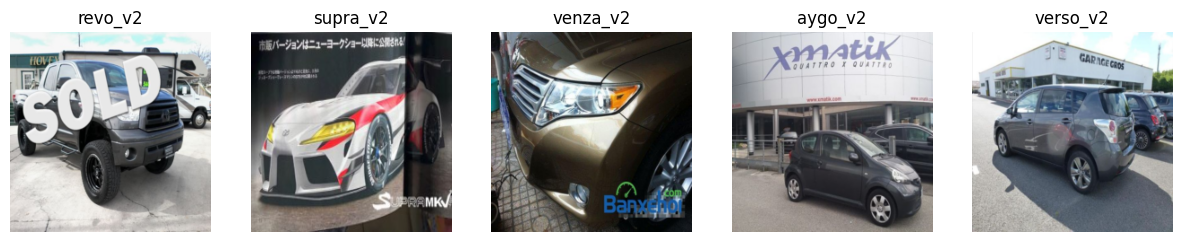

In [154]:
# TEST SET SAMPLE VISUALIZATION
plot_loader_data(test_loader)

In [155]:
class ClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        wf = lambda x: max(8, int(x * WIDTH_FACTOR))
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=wf(32), kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(wf(32))
        self.conv2 = nn.Conv2d(in_channels=wf(32), out_channels=wf(64), kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(wf(64))
        self.conv3 = nn.Conv2d(in_channels=wf(64), out_channels=wf(128), kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(wf(128))
        self.conv4 = nn.Conv2d(in_channels=wf(128), out_channels=wf(256), kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(wf(256))
        self.conv5 = nn.Conv2d(in_channels=wf(256), out_channels=wf(512), kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(wf(512))
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(wf(512) * (IMAGE_SIZE // 32) * (IMAGE_SIZE // 32), 512)
        self.bnfc = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, len(SELECTED_CLASSES))
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # 224 -> 112
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # 112 -> 56
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # 56 -> 28
        x = self.pool(F.relu(self.bn4(self.conv4(x)))) # 28 -> 14
        x = self.pool(F.relu(self.bn5(self.conv5(x)))) # 14 -> 7
        
        x = x.view(x.size(0), -1)  # flatten
        
        x = self.dropout(F.relu(self.bnfc(self.fc1(x))))
        x = self.fc2(x)
        
        return x

class SequentialClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        wf = lambda x: max(8, int(x * WIDTH_FACTOR))
        
        self.features = nn.Sequential(
            nn.Conv2d(3, wf(32), kernel_size=3, padding=1),
            nn.BatchNorm2d(wf(32)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 224 -> 112
            
            nn.Conv2d(wf(32), wf(64), kernel_size=3, padding=1),
            nn.BatchNorm2d(wf(64)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 112 -> 56
            
            nn.Conv2d(wf(64), wf(128), kernel_size=3, padding=1),
            nn.BatchNorm2d(wf(128)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 56 -> 28
            
            nn.Conv2d(wf(128), wf(256), kernel_size=3, padding=1),
            nn.BatchNorm2d(wf(256)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 28 -> 14
            
            nn.Conv2d(wf(256), wf(512), kernel_size=3, padding=1),
            nn.BatchNorm2d(wf(512)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 14 -> 7
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(wf(512) * (IMAGE_SIZE // 32) * (IMAGE_SIZE // 32), 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, len(SELECTED_CLASSES))
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [156]:
# ---------------------  TRAINING HELPERS  --------------------
def evaluate(model, loader, criterion):
    model.eval() # Disable Dropout/Batchnorm
    
    running_loss = 0.0
    running_correct = 0
    total_samples = 0
    
    with torch.no_grad(): # Disable gradient calculation (saves RAM/Speed)
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Metrics
            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size
            
            _, preds = torch.max(outputs, 1)
            running_correct += torch.sum(preds == labels.data).item()
            total_samples += batch_size
    
    avg_loss = running_loss / total_samples
    accuracy = 100.0 * running_correct / total_samples
    
    return avg_loss, accuracy

def train_one_epoch(model, loader, criterion, optimizer):
    model.train() # Enable Dropout/Batchnorm
    
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # 1. Forward
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels) # Keep as Tensor here for backward()

        # 2. Backward
        loss.backward()
        optimizer.step()

        # 3. Metrics
        batch_size = inputs.size(0)
        # Multiply avg batch loss by batch_size to get total loss for these images
        running_loss += loss.item() * batch_size 
        
        _, preds = torch.max(outputs, 1)
        running_correct += torch.sum(preds == labels.data).item()
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = 100.0 * running_correct / total_samples
    
    return epoch_loss, epoch_acc

def validate(model, loader, crit):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = crit(out, y)
            running_loss += loss.item()
    return running_loss / len(loader)

def balanced_weights():
        # Calculate class weights based on training set distribution
        class_counts = [0] * len(SELECTED_CLASSES)
        for _, label in train_set:
            class_counts[label] += 1
        
        counts = torch.tensor(class_counts, dtype=torch.float)
        weights = 1.0 / counts
        weights = weights / weights.sum()
        weights = weights.to(DEVICE)
        print("Class weights:", weights)
        return weights

def training_criterion(use_balanced_weights=False):
    if use_balanced_weights:
        weights = balanced_weights()
        return nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
    else:
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    
# --------------------------------------------------------------

In [157]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

def plot_training_history(h):
    ep = range(1, len(h["train_loss"]) + 1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(ep, h["train_loss"], label="train")
    plt.plot(ep, h["dev_loss"],   label="dev")
    plt.title("Loss"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.subplot(1,2,2)
    plt.plot(ep, h["train_acc"], label="train")
    plt.plot(ep, h["dev_acc"],   label="dev")
    plt.title("Accuracy (%)"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.tight_layout(); plt.show()

In [158]:
def train_model(ModelClass, use_balanced_weights=False, transfer_learning=False):
    if transfer_learning:
        model = ModelClass.to(DEVICE)
        print("Training via Transfer Learning")
    else:
        model = ModelClass().to(DEVICE)
    
    print("Training model:", model.__class__.__name__)
    
    criterion = training_criterion(use_balanced_weights)
    optimizer = optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_BASE)

    history = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}

    best_dev_loss = float('inf')
    wait = 0

    # tiempo inicial paara grabar cuanto dura el entrenamiento
    start_time = time.time()
    print("Starting training at: ", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time)))

    for epoch in range(1, EPOCHS_BASE + 1):
        # timestamp de la epoch actual
        epoch_start = time.time()
        start_str = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(epoch_start))
        
        if epoch <= WARMPUP_EPOCHS:
            # Linear warmup: goes from 0 to BASE_LR
            lr = BASE_LR * (epoch / WARMPUP_EPOCHS)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        
        if epoch > WARMPUP_EPOCHS:
            scheduler.step()
            
        dev_loss, dev_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(dev_acc)

        # duracion de la actual epoch
        epoch_time = time.time() - epoch_start
        
        if epoch % 5 == 0:
            print(f"[Epoch {epoch:02d} | LR] Current LR:", optimizer.param_groups[0]['lr'])
        
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            torch.save(model.state_dict(), f'models/{model.__class__.__name__}_best_model.pth')
            wait = 0
        else:
            wait += 1

        print(f"[Epoch {epoch:02d} | {timedelta(seconds=int(epoch_time))} ({epoch_time:.2f}s) | p={wait}/{PATIENCE}] "
            f"train_loss: {tr_loss:.3f} | train_acc: {tr_acc:5.2f}% | "
            f"dev_loss: {dev_loss:.3f} | dev_acc: {dev_acc:5.2f}%")

        if wait >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    total_time = time.time() - start_time
    print(f"\n=== TOTAL TRAINING TIME: {timedelta(seconds=int(total_time))} ({total_time:.2f}s) ===")

    print("\nLoading best model for final testing...")
    model.load_state_dict(torch.load(f'models/{model.__class__.__name__}_best_model.pth'))
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    print(f"=== FINAL TEST ACCURACY: {test_acc:.2f}% ===")

    plot_training_history(history)
    plot_confusion_matrix(model, test_loader, SELECTED_CLASSES)

Training model: SequentialClassifierCNN
Starting training at:  2025-12-04 16:19:55
[Epoch 01 | 0:00:09 (9.92s) | p=0/10] train_loss: 1.618 | train_acc: 36.79% | dev_loss: 1.797 | dev_acc: 16.67%
[Epoch 02 | 0:00:09 (9.03s) | p=0/10] train_loss: 1.418 | train_acc: 45.52% | dev_loss: 1.592 | dev_acc: 31.25%
[Epoch 03 | 0:00:09 (9.08s) | p=1/10] train_loss: 1.302 | train_acc: 52.83% | dev_loss: 2.223 | dev_acc: 27.08%
[Epoch 04 | 0:00:08 (8.43s) | p=2/10] train_loss: 1.265 | train_acc: 57.31% | dev_loss: 1.616 | dev_acc: 52.08%
[Epoch 05 | LR] Current LR: 0.000996057350657239
[Epoch 05 | 0:00:08 (8.82s) | p=3/10] train_loss: 1.152 | train_acc: 61.08% | dev_loss: 1.705 | dev_acc: 39.58%
[Epoch 06 | 0:00:09 (9.39s) | p=4/10] train_loss: 1.096 | train_acc: 64.62% | dev_loss: 1.730 | dev_acc: 41.67%
[Epoch 07 | 0:00:08 (8.62s) | p=0/10] train_loss: 1.009 | train_acc: 69.58% | dev_loss: 1.310 | dev_acc: 66.67%
[Epoch 08 | 0:00:08 (8.47s) | p=1/10] train_loss: 1.024 | train_acc: 67.92% | dev_lo

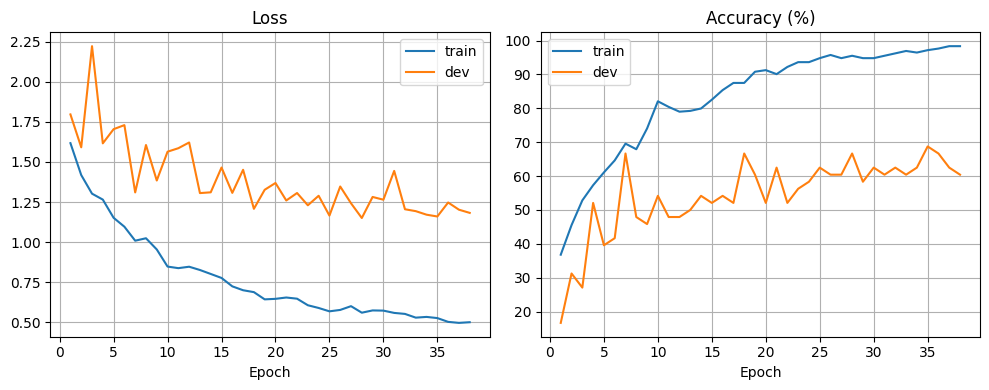

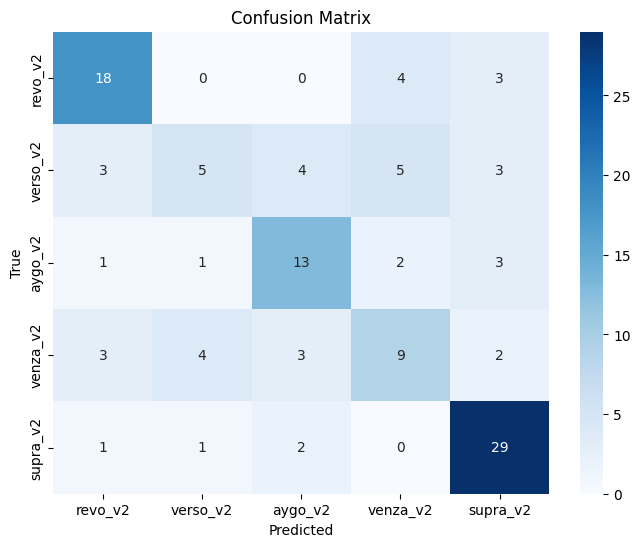

Training model: ClassifierCNN
Starting training at:  2025-12-04 16:24:57
[Epoch 01 | 0:00:07 (7.46s) | p=0/10] train_loss: 1.598 | train_acc: 35.38% | dev_loss: 1.607 | dev_acc: 22.92%
[Epoch 02 | 0:00:07 (7.78s) | p=1/10] train_loss: 1.363 | train_acc: 47.88% | dev_loss: 1.709 | dev_acc: 33.33%
[Epoch 03 | 0:00:08 (8.08s) | p=2/10] train_loss: 1.290 | train_acc: 54.95% | dev_loss: 2.429 | dev_acc: 33.33%
[Epoch 04 | 0:00:07 (7.05s) | p=3/10] train_loss: 1.220 | train_acc: 55.66% | dev_loss: 2.022 | dev_acc: 45.83%
[Epoch 05 | LR] Current LR: 0.000996057350657239
[Epoch 05 | 0:00:07 (7.35s) | p=0/10] train_loss: 1.133 | train_acc: 60.14% | dev_loss: 1.553 | dev_acc: 43.75%
[Epoch 06 | 0:00:08 (8.11s) | p=1/10] train_loss: 1.103 | train_acc: 63.68% | dev_loss: 1.714 | dev_acc: 41.67%
[Epoch 07 | 0:00:07 (7.60s) | p=2/10] train_loss: 1.101 | train_acc: 62.26% | dev_loss: 2.560 | dev_acc: 33.33%
[Epoch 08 | 0:00:06 (6.87s) | p=3/10] train_loss: 1.010 | train_acc: 68.87% | dev_loss: 1.730 

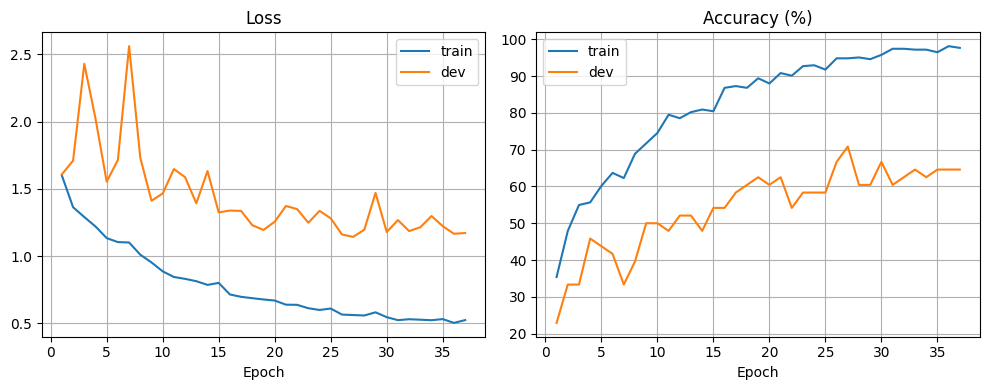

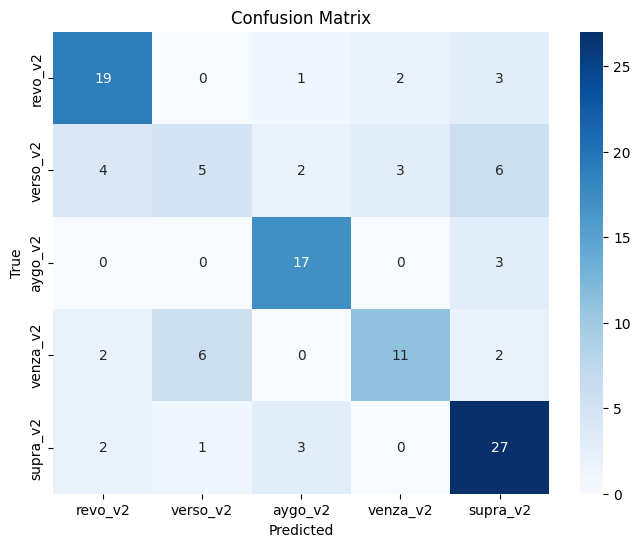

In [159]:
# --------------------------  TRAIN  ---------------------------
train_model(SequentialClassifierCNN)
train_model(ClassifierCNN)

In [160]:
# -------------------- VIA TRANSFER LEARNING --------------------
pretrained_model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, len(SELECTED_CLASSES))  # ajustar la capa final
)

train_model(pretrained_model, transfer_learning=True)

Training via Transfer Learning
Training model: ResNet
Starting training at:  2025-12-04 16:29:17
[Epoch 01 | 0:00:06 (6.46s) | p=0/10] train_loss: 1.357 | train_acc: 47.64% | dev_loss: 1.133 | dev_acc: 62.50%
[Epoch 02 | 0:00:06 (6.44s) | p=1/10] train_loss: 0.835 | train_acc: 80.66% | dev_loss: 1.630 | dev_acc: 54.17%
[Epoch 03 | 0:00:06 (6.14s) | p=2/10] train_loss: 0.917 | train_acc: 78.30% | dev_loss: 3.749 | dev_acc: 37.50%
[Epoch 04 | 0:00:06 (6.24s) | p=3/10] train_loss: 0.860 | train_acc: 81.84% | dev_loss: 2.258 | dev_acc: 39.58%
[Epoch 05 | LR] Current LR: 0.000996057350657239
[Epoch 05 | 0:00:06 (6.26s) | p=4/10] train_loss: 0.784 | train_acc: 82.55% | dev_loss: 1.450 | dev_acc: 56.25%
[Epoch 06 | 0:00:06 (6.24s) | p=0/10] train_loss: 0.765 | train_acc: 84.67% | dev_loss: 1.123 | dev_acc: 64.58%
[Epoch 07 | 0:00:06 (6.48s) | p=1/10] train_loss: 0.672 | train_acc: 88.68% | dev_loss: 1.702 | dev_acc: 52.08%
[Epoch 08 | 0:00:06 (6.43s) | p=0/10] train_loss: 0.565 | train_acc: 9

KeyboardInterrupt: 